#### This is the RABI Oscillation Notebook

##### In this experiment we will use the Pulseblaster, AOM, RF Switch and the Windfreak
##### The pulseblaster outputs should be connected as listed below:
###### 1. Output 0: Connect to AOM
###### 2. Output 1: Connect to Lock-in AMP REF IN input
###### 3. Output 23: Connect to the RF Switch TTL input

In [12]:
from Ametek_5210 import Ametek5210
from pulseblaster_d import pulseblasterd
from windfreak import windfreak

In [13]:
import numpy as np
import time
import datetime
import matplotlib.pyplot as plt
import csv

In [14]:
#initalize equiptment
pulser = pulseblasterd('pb')
rf = windfreak('windfreak', 'COM5')
lockin = Ametek5210('lockin', 'GPIB0::12::INSTR')

In [15]:
# This function determines the delay based on the tc of the lock in amp
def set_delay(lockin_tc):
    timeconst = {0: '1 ms',
    1: '3 ms',
    2: '10 ms',
    3: '30 ms' ,
    4: '100 ms',
    5: '300 ms',
    6: '1 s',
    7: '3 s',
    8: '10 s',
    9: '30 s',
    10: '100 s',
    11: '300 s',
    12: '1 ks',
    13: '3 ks'}

    timeconst_bw = {'1 ms' :0,
    '3 ms': 1,
    '10 ms': 2,
    '30 ms': 3 ,
    '100 ms': 4,
    '300 ms' : 5,
    '1 s' : 6,
    '3 s' : 7,
    '10 s': 8,
    '30 s': 9,
    '100 s': 10,
    '300 s': 11,
    '1 ks' : 12,
    '3 ks' : 13}

    tc_s = {0: 0.001,  #get timeconstant in secs
    1: 0.003,
    2: 0.01,
    3: 0.03 ,
    4: 0.1,
    5: 0.3,
    6: 1,
    7: 3,
    8: 10,
    9: 30,
    10: 100,
    11: 300,
    12: 1000,
    13: 3000}

    val = timeconst_bw[lockin_tc]
    if(type(val) != int):
        return "Error: invalid input!"
    else:
        return 5* tc_s[val]
    

#### The Rabi Oscillation experiment is implemented below:
#### 1. Make sure all the equipment is turned on
#### 2. There are some parameters in the beginning you can set to see how the results change based on the values you set

##### If you run into any issues please let the TA know!

delay: 5
1.2999999999999998e-06
26
1505.0
2026.0
2012.0
2148.0
2126.0
2108.0
2080.0
2041.0
2026.0
2028.0
2049.0
2084.0
2114.0
2133.0
2143.0
2143.0
2140.0
2136.0
2126.0
2133.0
2144.0
2155.0
2168.0
2181.0
2190.0
2195.0


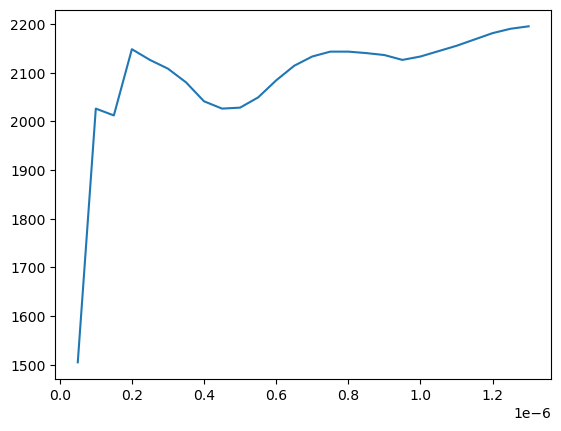

In [72]:
#TODO: set below parameters
rf_power = -5 #in dBm, do not exceed -10dBm (try -30 to -10 dBm)
rf_freq = 2813 #determined by the PulesdODMR or CWODMR (in MHz)

start_width = .05e-6 #set the shortest RF pulse length
end_width = 1.3e-6 #set the longest RF pulse length
width_step = .05e-6 #set the RF step size
rf_width = np.arange(start_width, end_width, width_step)

pulser._set_rf_width(0)
#set aom pulse length (optional- default is 5 microseconds)
pulser._set_aom_width(5e-6)

#create array of outputs from the lockin amp
vals = np.zeros(len(rf_width))

#turn on the RF module to the right frequency
rf.set_channel(0)
rf.set_power_dBm(rf_power) #-30 with amp, no more than -5dBm!
rf.set_freq(rf_freq)
#turn on windfreak
rf.on()

tc = '1 s' #use '300 ms' to get data faster, longer times for less noise

#set the sensitivity and the time constant of the lock in amp

lockin.sensitivity('10 mV') #or 30mV
time. sleep(1)
lockin.time_constant(tc) #1s


#set the delay based on the lockin sensitivity
delay = set_delay(tc)
print("delay: " + str(delay))

#set the width of the lock in pulse
pulser._set_lock_in_width(2.5e-3)
print(str(pulser._set_rf_width()))
num = len(rf_width)
print(num)

for i in range(num):
    pulser._set_rf_width(rf_width[i])
    pulser.program_pulsedstateV2(rf_width[num-1])
    pulser.start()
    time.sleep(delay)
    val = lockin.magnitude()
    vals[i] = val
    print(val)
    # pulser.stop()

rf.off()

plt.plot(rf_width, vals)
dt = str(datetime.datetime.now()).strip().replace(' ', '-').replace('.','-').replace(':',"-")
plt.savefig(f'outputs/sample-aom05-power{str(rf_power * -1)}.png')
plt.show()

In [65]:
pulser.stop()

In [74]:
#write data to a csv file to save the data

dt = str(datetime.datetime.now()).strip().replace(' ', '-').replace('.','-').replace(':',"-")
filename = "outputs/sample-aom05-power" + str(rf_power * -1) + ".csv"
header = ['rf_frequency(MHz)', 'Lock in amp mag']
with open(filename, 'w', newline='') as csvfile:
    csvwriter = csv.writer(csvfile)
    csvwriter.writerow(header)
    for i in range(len(vals)):
        row = [rf_width[i], vals[i]]
        print(row)
        csvwriter.writerow(row)

[5e-08, 1505.0]
[1e-07, 2026.0]
[1.5e-07, 2012.0]
[2e-07, 2148.0]
[2.5e-07, 2126.0]
[3e-07, 2108.0]
[3.5e-07, 2080.0]
[4e-07, 2041.0]
[4.5e-07, 2026.0]
[5e-07, 2028.0]
[5.5e-07, 2049.0]
[6e-07, 2084.0]
[6.499999999999999e-07, 2114.0]
[6.999999999999999e-07, 2133.0]
[7.5e-07, 2143.0]
[8e-07, 2143.0]
[8.499999999999999e-07, 2140.0]
[8.999999999999999e-07, 2136.0]
[9.5e-07, 2126.0]
[1e-06, 2133.0]
[1.05e-06, 2144.0]
[1.0999999999999998e-06, 2155.0]
[1.15e-06, 2168.0]
[1.2e-06, 2181.0]
[1.2499999999999999e-06, 2190.0]
[1.2999999999999998e-06, 2195.0]


### RABI FITTING CODE

In [2]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


In [8]:
filename = 'sample-aom40-power5.csv' #enter the file name & path(if it is not in the same folder) as a string

with open('outputs/' + filename, 'r') as f:
    reader = csv.reader(f)
    data = list(reader)

data_array = np.array(data)

rf_pulse_width = np.zeros(len(data_array)-1)
lock_in_mag = np.zeros(len(data_array)-1)
for i in range(len(data_array)):
    if i == 0:
        pass
    else:
        print(data_array[i])
        rf_pulse_width[i-1] = float(data_array[i][0])
        lock_in_mag[i-1] = float(data_array[i][1])

print(lock_in_mag)


['5e-08' '587.0']
['1e-07' '816.0']
['1.5e-07' '961.0']
['2e-07' '1084.0']
['2.5e-07' '1097.0']
['3e-07' '1054.0']
['3.5e-07' '994.0']
['4e-07' '932.0']
['4.5e-07' '889.0']
['5e-07' '897.0']
['5.5e-07' '936.0']
['6e-07' '985.0']
['6.499999999999999e-07' '1028.0']
['6.999999999999999e-07' '1062.0']
['7.5e-07' '1080.0']
['8e-07' '1074.0']
['8.499999999999999e-07' '1063.0']
['8.999999999999999e-07' '1044.0']
['9.5e-07' '1037.0']
['1e-06' '1032.0']
['1.05e-06' '1048.0']
['1.0999999999999998e-06' '1065.0']
['1.15e-06' '1073.0']
['1.2e-06' '1095.0']
['1.2499999999999999e-06' '1109.0']
['1.2999999999999998e-06' '1113.0']
[ 587.  816.  961. 1084. 1097. 1054.  994.  932.  889.  897.  936.  985.
 1028. 1062. 1080. 1074. 1063. 1044. 1037. 1032. 1048. 1065. 1073. 1095.
 1109. 1113.]


In [9]:
#TODO: set initial guesses for curve fitting
sinusoid_amp = 3000  #starting amp of signal
sinusoid_period = 2e-7 #time bewteen crests or troughs of the sine wave 
sinusoid_frequency = 1/sinusoid_period
phi = 0

In [10]:
#curve fit a damped sine to the data

def sine(times, frequency, phi ):
    return np.sin(frequency*times+phi)
def exp(times, amplitude, lbda):
    return amplitude*np.exp(-lbda*times)

def logb(times, base, y_offset):
    return (np.log(times) / np.log(base)) + y_offset

def damped_sin_func(times, amplitude, frequency, phi, ldba, shift):
    return exp(times, amplitude, ldba)*sine(times, frequency, phi)+shift

logpopt,logpconv = curve_fit(logb, #our function
                      rf_pulse_width, #measured x values
                      lock_in_mag, #measured y values
                      p0 = (100, 0))

decaying_exp_sin = logb(rf_pulse_width, logpopt[0], logpopt[1]) - lock_in_mag

popt,pcov = curve_fit(damped_sin_func, #our function
                      rf_pulse_width, #measured x values
                      decaying_exp_sin, #measured y values
                      p0 = (140, (1/0.2e-6), 0.1e-6, -0.2, 850))


C:\Users\QT3\AppData\Local\Temp\ipykernel_6880\1270705925.py:9: RuntimeWarning: invalid value encountered in log
  return (np.log(times) / np.log(base)) + y_offset


In [20]:
print(popt)
print(logpopt)
print(popt[1])

period = np.pi / popt[1]
print(f'Period: {period}')
print(f'Frequency: {popt[1]}')
print(f'Decay Rate: {popt[3]}')

[-3.10666159e+02  1.19991216e+07 -1.29451022e+00  2.38864162e+06
  7.25278909e+00]
[1.00994510e+00 2.46665949e+03]
11999121.62140634
Period: 2.618185524501407e-07
Frequency: 11999121.62140634
Decay Rate: 2388641.620060777


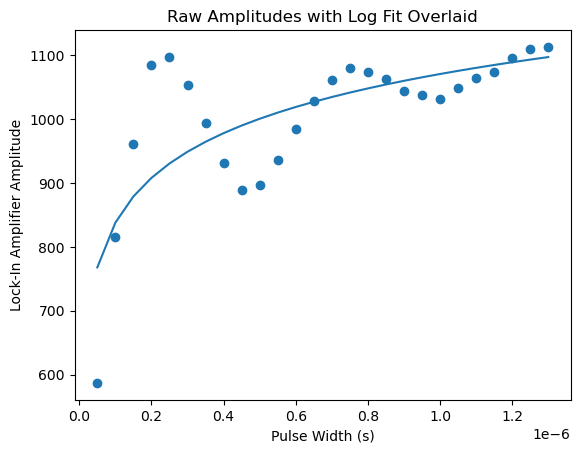

In [46]:
plt.plot(rf_pulse_width, lock_in_mag, 'o')
# plt.plot(rf_pulse_width, damped_sin_func(rf_pulse_width, popt[0], popt[1], popt[2], popt[3], popt[4]) - lock_in_mag)
plt.plot(rf_pulse_width, logb(rf_pulse_width, logpopt[0], logpopt[1]), color="tab:blue")
plt.title("Raw Amplitudes with Log Fit Overlaid")
plt.ylabel("Lock-In Amplifier Amplitude")
plt.xlabel("Pulse Width (s)")
plt.show()

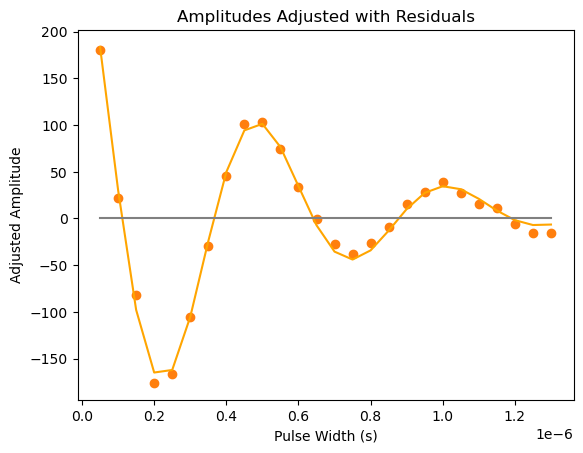

In [ ]:
plt.plot(rf_pulse_width, decaying_exp_sin, 'o', color="tab:orange")
plt.plot(rf_pulse_width, damped_sin_func(rf_pulse_width, popt[0], popt[1], popt[2], popt[3], popt[4]), color="tab:orange")
plt.plot(rf_pulse_width, np.zeros(len(rf_pulse_width)), color="gray")
plt.title("Amplitudes Adjusted with Residuals")
plt.ylabel("Adjusted Amplitude")
plt.xlabel("Pulse Width (s)")
plt.show()